# 4-Class Defect Detection — TFLite Quantization Study

This notebook converts and evaluates four trained 4-class defect detection models in three
TFLite quantization formats:

| Model | Source file |
|-------|------------|
| MobileNetV2 (All-layers FT) | `mobilenetv2_4class_alllayers_final.h5` |
| MobileNetV3Small (FT) | `best_mobilenetv3_small_finetuned.weights.h5` |
| MobileNetV3Large (FT) | `best_mobilenetv3_large_finetuned.weights.h5` |
| Custom CA-CNN | `best_custom_ca_cnn_finetuned.weights.h5` |

**Three quantization formats per model:**
- `float32` — no quantization (baseline)
- `float16` — weight quantization to fp16
- `int8` — full-integer quantization (representative dataset: 200 training images)

**Evaluation metrics (CPU-only):**  
File size · Accuracy · Per-class Precision / Recall / F1 · Inference time (avg over 100 images)

---
## 1. Imports & Configuration

In [2]:
print(5)

5


In [3]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE              = os.getcwd()
TEST_DIR          = os.path.join(BASE, "splitted data", "test")
TRAIN_DIR         = os.path.join(BASE, "splitted data", "train")
TFLITE_DIR        = os.path.join(BASE, "tflite_4class")
os.makedirs(TFLITE_DIR, exist_ok=True)

# ── Model weight files ────────────────────────────────────────────────────────
MODEL_FILES = {
    "MobileNetV2":     os.path.join(BASE, "mobilenetv2_4class_alllayers_final.h5"),
    "MobileNetV3Small": os.path.join(BASE, "best_mobilenetv3_small_finetuned.weights.h5"),
    "MobileNetV3Large": os.path.join(BASE, "best_mobilenetv3_large_finetuned.weights.h5"),
    "CA-CNN":           os.path.join(BASE, "best_custom_ca_cnn_finetuned.weights.h5"),
}

# ── Constants ─────────────────────────────────────────────────────────────────
IMG_SIZE      = (224, 224)
NUM_CLASSES   = 4
CLASS_NAMES   = ["Cracking", "Stringing", "Warping", "No_Defect"]
SEED          = 42
REPR_N        = 200   # representative dataset size for INT8
TIMING_N      = 100   # images used for inference timing
NUM_THREADS   = 1     # CPU threads for TFLite (keep 1 for fair timing)

print(f"TensorFlow version : {tf.__version__}")
print(f"TFLite models will be saved to: {TFLITE_DIR}")

2026-05-28 14:32:02.726791: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779975122.751392   27424 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779975122.758306   27424 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-28 14:32:02.788289: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version : 2.18.0
TFLite models will be saved to: /home/feriel/PFE/Defect-Detection/tflite_4class


---
## 2. Load Test & Representative-Dataset Paths

In [4]:
def get_paths_and_labels(folder_path, class_names=CLASS_NAMES):
    """Walk a split folder and return (paths_array, labels_array)."""
    paths, labels = [], []
    class_map = {name: idx for idx, name in enumerate(class_names)}
    for class_name in class_names:
        class_dir = os.path.join(folder_path, class_name)
        if not os.path.isdir(class_dir):
            continue
        for f in sorted(os.listdir(class_dir)):
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                paths.append(os.path.join(class_dir, f))
                labels.append(class_map[class_name])
    return np.array(paths), np.array(labels)


test_paths,  test_labels  = get_paths_and_labels(TEST_DIR)
train_paths, train_labels = get_paths_and_labels(TRAIN_DIR)

# Shuffle training paths for representative-dataset sampling
rng = np.random.default_rng(SEED)
idx = rng.permutation(len(train_paths))
train_paths  = train_paths[idx]
train_labels = train_labels[idx]

print(f"Test images  : {len(test_paths)}")
print(f"Train images : {len(train_paths)}  (first {REPR_N} used for INT8 calibration)")

Test images  : 776
Train images : 6187  (first 200 used for INT8 calibration)


In [5]:
def load_image_float32(path):
    """Load, resize and normalise a single image → float32 (1, 224, 224, 3) in [0,1]."""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img.numpy()[np.newaxis, ...]   # shape (1, 224, 224, 3)


# ── Pre-load test images (float32) for uniform evaluation ────────────────────
print("Pre-loading test images …")
test_images = np.array([
    load_image_float32(p)[0] for p in test_paths
], dtype=np.float32)
print(f"test_images shape: {test_images.shape}")

Pre-loading test images …


I0000 00:00:1779975125.200103   27424 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


test_images shape: (776, 224, 224, 3)


---
## 3. Reconstruct Keras Models & Load Weights

> **MobileNetV2** is saved as a complete `.h5` (architecture + weights) — loaded directly.  
> The other three models were saved with `save_weights_only=True`, so their architecture
> must be reconstructed before loading the weight file.

### 3a. MobileNetV2 (All-Layers Fine-Tuned)

In [6]:
# MobileNetV2 was saved as a full model file
model_v2 = keras.models.load_model(MODEL_FILES["MobileNetV2"])
model_v2.trainable = False   # inference only
print(f"MobileNetV2 loaded — params: {model_v2.count_params():,}")

MobileNetV2 loaded — params: 2,586,948


### 3b. MobileNetV3Small (Fine-Tuned)

In [7]:
def build_mobilenetv3_small():
    base = tf.keras.applications.MobileNetV3Small(
        input_shape=(224, 224, 3),
        include_top=False,
        weights=None,                 # weights loaded separately
        include_preprocessing=False,  # pipeline already normalises to [0,1]
    )
    inp = layers.Input(shape=(224, 224, 3))
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation="relu")(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return keras.Model(inp, out, name="MobileNetV3Small_Model")


model_v3s = build_mobilenetv3_small()
model_v3s.load_weights(MODEL_FILES["MobileNetV3Small"])
model_v3s.trainable = False
print(f"MobileNetV3Small loaded — params: {model_v3s.count_params():,}")

MobileNetV3Small loaded — params: 1,087,860


### 3c. MobileNetV3Large (Fine-Tuned)

In [8]:
def build_mobilenetv3_large():
    base = tf.keras.applications.MobileNetV3Large(
        input_shape=(224, 224, 3),
        include_top=False,
        weights=None,
        include_preprocessing=False,
    )
    inp = layers.Input(shape=(224, 224, 3))
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation="relu")(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return keras.Model(inp, out, name="MobileNetV3Large_Model")


model_v3l = build_mobilenetv3_large()
model_v3l.load_weights(MODEL_FILES["MobileNetV3Large"])
model_v3l.trainable = False
print(f"MobileNetV3Large loaded — params: {model_v3l.count_params():,}")

MobileNetV3Large loaded — params: 3,243,396


### 3d. Custom CA-CNN (Coordinate Attention CNN)

In [9]:
# ── Coordinate Attention custom layer ────────────────────────────────────────
class CoordinateAttention(layers.Layer):
    """Lightweight spatial attention that captures H and W context independently."""

    def __init__(self, reduction=32, **kwargs):
        super().__init__(**kwargs)
        self.reduction = reduction

    def build(self, input_shape):
        C = input_shape[-1]
        mid_ch = max(8, C // self.reduction)
        self.shared_conv = layers.Conv2D(mid_ch, 1, padding="same", use_bias=False)
        self.bn           = layers.BatchNormalization()
        self.relu         = layers.ReLU(max_value=6.0)
        self.conv_h       = layers.Conv2D(C, 1, padding="same")
        self.conv_w       = layers.Conv2D(C, 1, padding="same")
        super().build(input_shape)

    def call(self, x, training=False):
        H = tf.shape(x)[1]
        pool_h   = tf.reduce_mean(x, axis=2, keepdims=True)          # (B,H,1,C)
        pool_w   = tf.reduce_mean(x, axis=1, keepdims=True)          # (B,1,W,C)
        pool_w_t = tf.transpose(pool_w, perm=[0, 2, 1, 3])           # (B,W,1,C)
        y  = tf.concat([pool_h, pool_w_t], axis=1)                   # (B,H+W,1,C)
        y  = self.relu(self.bn(self.shared_conv(y), training=training))
        y_h = y[:, :H, :, :]
        y_w = y[:, H:, :, :]
        a_h = tf.sigmoid(self.conv_h(y_h))                           # (B,H,1,C)
        a_w = tf.transpose(tf.sigmoid(self.conv_w(y_w)), [0,2,1,3]) # (B,1,W,C)
        return x * a_h * a_w

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"reduction": self.reduction})
        return cfg


# ── Inverse Residual Block ────────────────────────────────────────────────────
def inv_res_block(x, out_channels, stride=1, expand=6, name_prefix="irb"):
    in_channels  = x.shape[-1]
    mid_channels = in_channels * expand
    shortcut     = x
    if expand != 1:
        x = layers.Conv2D(mid_channels, 1, padding="same", use_bias=False,
                          name=f"{name_prefix}_expand_conv")(x)
        x = layers.BatchNormalization(name=f"{name_prefix}_expand_bn")(x)
        x = layers.ReLU(max_value=6.0, name=f"{name_prefix}_expand_relu")(x)
    x = layers.DepthwiseConv2D(3, strides=stride, padding="same", use_bias=False,
                               name=f"{name_prefix}_dw_conv")(x)
    x = layers.BatchNormalization(name=f"{name_prefix}_dw_bn")(x)
    x = layers.ReLU(max_value=6.0, name=f"{name_prefix}_dw_relu")(x)
    x = CoordinateAttention(reduction=32, name=f"{name_prefix}_ca")(x)
    x = layers.Conv2D(out_channels, 1, padding="same", use_bias=False,
                      name=f"{name_prefix}_proj_conv")(x)
    x = layers.BatchNormalization(name=f"{name_prefix}_proj_bn")(x)
    if stride == 1 and in_channels == out_channels:
        x = layers.Add(name=f"{name_prefix}_add")([shortcut, x])
    return x


# ── Full CA-CNN ───────────────────────────────────────────────────────────────
def build_custom_ca_cnn(num_classes=4, input_shape=(224, 224, 3)):
    inp = layers.Input(shape=input_shape, name="input")
    x   = layers.Conv2D(32, 3, strides=2, padding="same", use_bias=False,
                        name="stem_conv")(inp)
    x   = layers.BatchNormalization(name="stem_bn")(x)
    x   = layers.ReLU(max_value=6.0, name="stem_relu")(x)
    x   = inv_res_block(x, 16,  stride=1, expand=1, name_prefix="irb1")
    x   = inv_res_block(x, 24,  stride=2, expand=6, name_prefix="irb2")
    x   = inv_res_block(x, 32,  stride=2, expand=6, name_prefix="irb3")
    x   = inv_res_block(x, 64,  stride=2, expand=6, name_prefix="irb4")
    x   = inv_res_block(x, 96,  stride=1, expand=6, name_prefix="irb5")
    x   = layers.Conv2D(128, 1, padding="same", use_bias=False,
                        name="trans_conv")(x)
    x   = layers.BatchNormalization(name="trans_bn")(x)
    x   = layers.ReLU(max_value=6.0, name="trans_relu")(x)
    x   = layers.GlobalAveragePooling2D(name="gap")(x)
    x   = layers.Dense(256, activation="relu", name="fc1")(x)
    x   = layers.Dropout(0.3, name="drop")(x)
    out = layers.Dense(num_classes, activation="softmax", name="predictions")(x)
    return keras.Model(inp, out, name="Custom_CA_CNN")


model_ca = build_custom_ca_cnn(num_classes=NUM_CLASSES)
model_ca.load_weights(MODEL_FILES["CA-CNN"])
model_ca.trainable = False
print(f"CA-CNN loaded — params: {model_ca.count_params():,}")

CA-CNN loaded — params: 182,180


In [10]:
# Collect all Keras models in a dict for the quantization loop
KERAS_MODELS = {
    "MobileNetV2":      model_v2,
    "MobileNetV3Small": model_v3s,
    "MobileNetV3Large": model_v3l,
    "CA-CNN":           model_ca,
}

for name, m in KERAS_MODELS.items():
    print(f"{name:<20} params={m.count_params():>10,}")

MobileNetV2          params= 2,586,948
MobileNetV3Small     params= 1,087,860
MobileNetV3Large     params= 3,243,396
CA-CNN               params=   182,180


---
## 4. Quantization Helper Functions

Three conversion functions (one per format) and one TFLite evaluation function.

In [11]:
# ── Representative dataset (INT8 calibration) ────────────────────────────────
def make_representative_dataset(image_paths, n=REPR_N):
    """Return a generator that yields (1,224,224,3) float32 batches."""
    paths = image_paths[:n]
    def generator():
        for p in paths:
            yield [load_image_float32(p)]
    return generator


# ── Internal helper: get a traced concrete function for TFLite ────────────────
def _get_concrete_function(keras_model):
    """
    Trace the model with a fixed input signature.

    Uses tf.function + get_concrete_function, which bypasses the legacy
    Keras-2 internal APIs that TFLiteConverter.from_keras_model() relies
    on — those APIs do not exist in Keras 3 (TF 2.18+) and cause:
        TypeError: 'NoneType' object is not callable
    """
    @tf.function(
        input_signature=[tf.TensorSpec(shape=[1, 224, 224, 3], dtype=tf.float32)]
    )
    def infer(x):
        return keras_model(x, training=False)

    return infer.get_concrete_function()


# ── Conversion helpers ────────────────────────────────────────────────────────
def to_tflite_float32(keras_model):
    """TFLite float32 baseline (no quantization)."""
    cf   = _get_concrete_function(keras_model)
    conv = tf.lite.TFLiteConverter.from_concrete_functions([cf])
    return conv.convert()


def to_tflite_float16(keras_model):
    """TFLite float16 weight quantization."""
    cf   = _get_concrete_function(keras_model)
    conv = tf.lite.TFLiteConverter.from_concrete_functions([cf])
    conv.optimizations = [tf.lite.Optimize.DEFAULT]
    conv.target_spec.supported_types = [tf.float16]
    return conv.convert()


def to_tflite_int8(keras_model, repr_dataset_gen):
    """TFLite full-integer INT8 quantization.

    Inputs/outputs stay float32 so evaluation code is identical for
    all three formats.
    """
    cf   = _get_concrete_function(keras_model)
    conv = tf.lite.TFLiteConverter.from_concrete_functions([cf])
    conv.optimizations = [tf.lite.Optimize.DEFAULT]
    conv.representative_dataset = repr_dataset_gen
    conv.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
        tf.lite.OpsSet.TFLITE_BUILTINS,   # fallback for non-INT8-able ops
        tf.lite.OpsSet.SELECT_TF_OPS,     # fallback for custom / TF ops
    ]
    conv.inference_input_type  = tf.float32
    conv.inference_output_type = tf.float32
    return conv.convert()


# ── Save TFLite model to disk ─────────────────────────────────────────────────
def save_tflite(tflite_bytes, model_name, fmt):
    """Write bytes to TFLITE_DIR and return the file path."""
    filename = f"{model_name.replace(' ', '_')}_{fmt}.tflite"
    path     = os.path.join(TFLITE_DIR, filename)
    with open(path, "wb") as f:
        f.write(tflite_bytes)
    return path


print("✅ Conversion helpers defined (using from_concrete_functions — Keras 3 compatible).")


✅ Conversion helpers defined (using from_concrete_functions — Keras 3 compatible).


In [12]:
# ── TFLite evaluation function ────────────────────────────────────────────────
def evaluate_tflite(tflite_path, images, labels, timing_n=TIMING_N, num_threads=NUM_THREADS):
    """
    Evaluate a TFLite model on `images` (N,224,224,3) float32 — CPU only.

    The interpreter is first attempted with the default XNNPACK delegate.
    If XNNPACK fails to prepare (common for INT8 models that use hard-swish
    or other ops not yet supported by XNNPACK's INT8 path), we transparently
    fall back to the pure built-in op kernels without any delegate.

    Returns a dict with:
      size_mb      : file size in MB
      accuracy     : overall accuracy (%)
      precision    : macro precision (%)
      recall       : macro recall (%)
      f1_macro     : macro F1 (%)
      f1_per_class : dict of per-class F1 (%)
      inf_ms       : avg single-image inference time (ms)
      delegate     : 'xnnpack' or 'builtin' (which backend was used)
    """
    # ── File size ──────────────────────────────────────────────────────────────
    size_mb = os.path.getsize(tflite_path) / (1024 ** 2)

    # ── Build interpreter with XNNPACK → fallback to built-in kernels ──────────
    def _make_interp(use_delegates=True):
        if use_delegates:
            return tf.lite.Interpreter(
                model_path=tflite_path,
                num_threads=num_threads,
            )
        else:
            # Disable XNNPACK (and all other default delegates)
            return tf.lite.Interpreter(
                model_path=tflite_path,
                num_threads=num_threads,
                experimental_op_resolver_type=(
                    tf.lite.experimental.OpResolverType
                    .BUILTIN_WITHOUT_DEFAULT_DELEGATES
                ),
            )

    delegate_used = "xnnpack"
    interp = _make_interp(use_delegates=True)
    try:
        interp.allocate_tensors()
    except RuntimeError:
        # XNNPACK could not prepare the graph for this model/format.
        # Fall back to pure built-in kernels — slower but universally compatible.
        delegate_used = "builtin"
        interp = _make_interp(use_delegates=False)
        interp.allocate_tensors()

    inp_det = interp.get_input_details()[0]
    out_det = interp.get_output_details()[0]
    inp_idx = inp_det["index"]
    out_idx = out_det["index"]

    # ── Full predictions ───────────────────────────────────────────────────────
    preds = []
    for img in images:
        interp.set_tensor(inp_idx, img[np.newaxis, ...])   # (1,224,224,3)
        interp.invoke()
        preds.append(np.argmax(interp.get_tensor(out_idx)[0]))
    preds = np.array(preds)

    # ── Metrics ───────────────────────────────────────────────────────────────
    acc  = accuracy_score(labels, preds) * 100
    prec = precision_score(labels, preds, average="macro", zero_division=0) * 100
    rec  = recall_score(labels, preds, average="macro", zero_division=0)    * 100
    f1   = f1_score(labels, preds, average="macro", zero_division=0)        * 100
    f1_pc = {
        cn: v * 100
        for cn, v in zip(
            CLASS_NAMES,
            f1_score(labels, preds, average=None, zero_division=0),
        )
    }

    # ── Inference timing (single-image, avg over timing_n) ───────────────────
    timing_imgs = images[:timing_n]
    # warmup (5 passes)
    for img in timing_imgs[:5]:
        interp.set_tensor(inp_idx, img[np.newaxis, ...])
        interp.invoke()

    times = []
    for img in timing_imgs:
        interp.set_tensor(inp_idx, img[np.newaxis, ...])
        t0 = time.perf_counter()
        interp.invoke()
        times.append((time.perf_counter() - t0) * 1000)  # ms
    inf_ms = float(np.mean(times))

    return {
        "size_mb":      round(size_mb, 2),
        "accuracy":     round(acc, 2),
        "precision":    round(prec, 2),
        "recall":       round(rec, 2),
        "f1_macro":     round(f1, 2),
        "f1_per_class": {k: round(v, 2) for k, v in f1_pc.items()},
        "inf_ms":       round(inf_ms, 2),
        "delegate":     delegate_used,
    }


---
## 5. Step 2 — Convert All Models to TFLite (3 Formats Each)

Conversion can take a few minutes per model, especially INT8 with calibration.

In [13]:
import traceback

# ── Re-build KERAS_MODELS fresh here so a kernel restart between cells
#    never leaves stale/None references in the dict ──────────────────────────
# (If a model variable is somehow None, we catch it with a clear error.)

def _safe_load_keras_models():
    models = {}

    # MobileNetV2 — full .h5
    try:
        m = keras.models.load_model(MODEL_FILES["MobileNetV2"])
        m.trainable = False
        models["MobileNetV2"] = m
        print(f"  MobileNetV2      OK  ({m.count_params():,} params)")
    except Exception:
        print("  MobileNetV2      FAILED to load:")
        traceback.print_exc()
        models["MobileNetV2"] = None

    # MobileNetV3Small — rebuild + load weights
    try:
        m = build_mobilenetv3_small()
        m.load_weights(MODEL_FILES["MobileNetV3Small"])
        m.trainable = False
        models["MobileNetV3Small"] = m
        print(f"  MobileNetV3Small OK  ({m.count_params():,} params)")
    except Exception:
        print("  MobileNetV3Small FAILED to load:")
        traceback.print_exc()
        models["MobileNetV3Small"] = None

    # MobileNetV3Large — rebuild + load weights
    try:
        m = build_mobilenetv3_large()
        m.load_weights(MODEL_FILES["MobileNetV3Large"])
        m.trainable = False
        models["MobileNetV3Large"] = m
        print(f"  MobileNetV3Large OK  ({m.count_params():,} params)")
    except Exception:
        print("  MobileNetV3Large FAILED to load:")
        traceback.print_exc()
        models["MobileNetV3Large"] = None

    # CA-CNN — rebuild + load weights
    try:
        m = build_custom_ca_cnn(num_classes=NUM_CLASSES)
        m.load_weights(MODEL_FILES["CA-CNN"])
        m.trainable = False
        models["CA-CNN"] = m
        print(f"  CA-CNN           OK  ({m.count_params():,} params)")
    except Exception:
        print("  CA-CNN           FAILED to load:")
        traceback.print_exc()
        models["CA-CNN"] = None

    return models


print("Loading / rebuilding all Keras models …")
KERAS_MODELS = _safe_load_keras_models()
print()

# ── Verify: stop early if any model is None ───────────────────────────────────
broken = [n for n, m in KERAS_MODELS.items() if m is None]
if broken:
    raise RuntimeError(
        f"The following models could not be loaded: {broken}\n"
        "Fix the loading errors above, then re-run this cell."
    )
print("All models loaded successfully.\n")

# ── Conversion loop ───────────────────────────────────────────────────────────
FORMATS      = ["float32", "float16", "int8"]
tflite_paths = {name: {} for name in KERAS_MODELS}

for model_name, keras_model in KERAS_MODELS.items():
    print(f"\n{'='*60}")
    print(f"  Converting: {model_name}")
    print(f"{'='*60}")

    # float32
    print("  [1/3] float32 …", end=" ", flush=True)
    try:
        tflite_bytes = to_tflite_float32(keras_model)
        path = save_tflite(tflite_bytes, model_name, "float32")
        tflite_paths[model_name]["float32"] = path
        print(f"OK  →  {os.path.getsize(path)/1024**2:.1f} MB")
    except Exception:
        print("FAILED")
        traceback.print_exc()

    # float16
    print("  [2/3] float16 …", end=" ", flush=True)
    try:
        tflite_bytes = to_tflite_float16(keras_model)
        path = save_tflite(tflite_bytes, model_name, "float16")
        tflite_paths[model_name]["float16"] = path
        print(f"OK  →  {os.path.getsize(path)/1024**2:.1f} MB")
    except Exception:
        print("FAILED")
        traceback.print_exc()

    # int8
    print("  [3/3] int8 …", end=" ", flush=True)
    try:
        repr_gen     = make_representative_dataset(train_paths, n=REPR_N)
        tflite_bytes = to_tflite_int8(keras_model, repr_gen)
        path = save_tflite(tflite_bytes, model_name, "int8")
        tflite_paths[model_name]["int8"] = path
        print(f"OK  →  {os.path.getsize(path)/1024**2:.1f} MB")
    except Exception:
        print("FAILED")
        traceback.print_exc()

print("\n✅ Conversion loop finished.")


Loading / rebuilding all Keras models …


  MobileNetV2      OK  (2,586,948 params)
  MobileNetV3Small OK  (1,087,860 params)
  MobileNetV3Large OK  (3,243,396 params)
  CA-CNN           OK  (182,180 params)

All models loaded successfully.


  Converting: MobileNetV2
  [1/3] float32 … 

I0000 00:00:1779975161.172446   27424 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1779975161.172676   27424 single_machine.cc:361] Starting new session
I0000 00:00:1779975161.173364   27424 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


OK  →  9.7 MB
  [2/3] float16 … 

W0000 00:00:1779975162.391970   27424 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1779975162.392031   27424 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-05-28 14:32:42.730246: I tensorflow/compiler/mlir/lite/flatbuffer_export.cc:3893] Estimated count of arithmetic ops: 606.541 M  ops, equivalently 303.270 M  MACs
I0000 00:00:1779975163.562897   27424 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1779975163.563129   27424 single_machine.cc:361] Starting new session
I0000 00:00:1779975163.563842   27424 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


...

W0000 00:00:1779975234.055111   27424 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1779975234.055169   27424 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-05-28 14:33:54.173254: I tensorflow/compiler/mlir/lite/flatbuffer_export.cc:3893] Estimated count of arithmetic ops: 186.223 M  ops, equivalently 93.111 M  MACs
I0000 00:00:1779975234.697932   27424 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1779975234.698125   27424 single_machine.cc:361] Starting new session
I0000 00:00:1779975234.699025   27424 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


OK  →  0.4 MB
  [3/3] int8 … 

W0000 00:00:1779975235.290377   27424 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1779975235.290425   27424 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-05-28 14:33:55.391560: I tensorflow/compiler/mlir/lite/flatbuffer_export.cc:3893] Estimated count of arithmetic ops: 186.223 M  ops, equivalently 93.111 M  MACs
I0000 00:00:1779975236.314620   27424 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1779975236.314896   27424 single_machine.cc:361] Starting new session
I0000 00:00:1779975236.315567   27424 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5
W0000 00:00:1779975236.919731   27424 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1779975236.919777   27424 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_contro

OK  →  0.3 MB

✅ Conversion loop finished.


fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32
2026-05-28 14:34:16.115594: I tensorflow/compiler/mlir/lite/flatbuffer_export.cc:3893] Estimated count of arithmetic ops: 186.223 M  ops, equivalently 93.111 M  MACs


---
## 6. Step 3 — Evaluate All TFLite Models on the Test Set

Runs on **CPU only** (single thread) for reproducible inference timing.

In [14]:
all_results = []   # list of dicts, one row per (model, format)

for model_name, fmt_paths in tflite_paths.items():
    for fmt in FORMATS:
        if fmt not in fmt_paths:
            print(f"  SKIP {model_name} / {fmt}  (conversion failed)")
            continue

        path = fmt_paths[fmt]
        print(f"  Evaluating  {model_name:<20} [{fmt:<8}] …", end=" ", flush=True)

        metrics = evaluate_tflite(
            tflite_path=path,
            images=test_images,
            labels=test_labels,
        )

        row = {
            "Model":  model_name,
            "Format": fmt,
            **metrics,
        }
        all_results.append(row)

        print(
            f"acc={metrics['accuracy']:.2f}%  "
            f"f1={metrics['f1_macro']:.2f}%  "
            f"size={metrics['size_mb']:.1f}MB  "
            f"inf={metrics['inf_ms']:.1f}ms"
        )

print("\n✅ Evaluation complete.")

  Evaluating  MobileNetV2          [float32 ] … 

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


acc=99.74%  f1=99.76%  size=9.7MB  inf=9.4ms
  Evaluating  MobileNetV2          [float16 ] … acc=99.74%  f1=99.76%  size=4.9MB  inf=8.2ms
  Evaluating  MobileNetV2          [int8    ] … acc=99.61%  f1=99.65%  size=2.9MB  inf=9.6ms
  Evaluating  MobileNetV3Small     [float32 ] … acc=98.71%  f1=98.83%  size=4.1MB  inf=1.9ms
  Evaluating  MobileNetV3Small     [float16 ] … acc=98.71%  f1=98.83%  size=2.1MB  inf=2.0ms
  Evaluating  MobileNetV3Small     [int8    ] … acc=81.83%  f1=82.61%  size=1.3MB  inf=9.8ms
  Evaluating  MobileNetV3Large     [float32 ] … acc=99.36%  f1=99.41%  size=12.3MB  inf=7.2ms
  Evaluating  MobileNetV3Large     [float16 ] … acc=99.36%  f1=99.41%  size=6.2MB  inf=7.2ms
  Evaluating  MobileNetV3Large     [int8    ] … acc=71.65%  f1=73.37%  size=3.6MB  inf=27.1ms
  Evaluating  CA-CNN               [float32 ] … acc=99.74%  f1=99.76%  size=0.7MB  inf=3.4ms
  Evaluating  CA-CNN               [float16 ] … acc=99.74%  f1=99.76%  size=0.4MB  inf=3.6ms
  Evaluating  CA-CNN   

In [15]:
# Print per-class F1 breakdown
print("\n" + "="*80)
print("Per-class F1-Score breakdown")
print("="*80)
for r in all_results:
    print(f"\n{r['Model']} [{r['Format']}]")
    for cls, f1 in r['f1_per_class'].items():
        print(f"  {cls:<15} {f1:.2f}%")


Per-class F1-Score breakdown

MobileNetV2 [float32]
  Cracking        100.00%
  Stringing       99.61%
  Warping         100.00%
  No_Defect       99.45%

MobileNetV2 [float16]
  Cracking        100.00%
  Stringing       99.61%
  Warping         100.00%
  No_Defect       99.45%

MobileNetV2 [int8]
  Cracking        100.00%
  Stringing       99.42%
  Warping         100.00%
  No_Defect       99.17%

MobileNetV3Small [float32]
  Cracking        100.00%
  Stringing       98.04%
  Warping         100.00%
  No_Defect       97.27%

MobileNetV3Small [float16]
  Cracking        100.00%
  Stringing       98.04%
  Warping         100.00%
  No_Defect       97.27%

MobileNetV3Small [int8]
  Cracking        83.22%
  Stringing       76.97%
  Warping         100.00%
  No_Defect       70.25%

MobileNetV3Large [float32]
  Cracking        100.00%
  Stringing       99.03%
  Warping         100.00%
  No_Defect       98.62%

MobileNetV3Large [float16]
  Cracking        100.00%
  Stringing       99.03%
  W

---
## 7. Step 4 — Comparison Table

| Column | Description |
|--------|-------------|
| **Size (MB)** | TFLite file size on disk |
| **Acc (%)** | Test-set accuracy |
| **Prec (%)** | Macro-average precision |
| **Rec (%)** | Macro-average recall |
| **F1 (%)** | Macro-average F1 |
| **Inf (ms)** | Avg single-image CPU inference time |

In [16]:
df = pd.DataFrame([
    {
        "Model":      r["Model"],
        "Format":     r["Format"],
        "Size (MB)":  r["size_mb"],
        "Acc (%)": r["accuracy"],
        "Prec (%)": r["precision"],
        "Rec (%)": r["recall"],
        "F1 (%)": r["f1_macro"],
        "Inf (ms)": r["inf_ms"],
    }
    for r in all_results
])

# Pretty-print with pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:.2f}".format)
print(df.to_string(index=False))

# Save to CSV
csv_path = os.path.join(BASE, "quantization_4class_results.csv")
df.to_csv(csv_path, index=False)
print(f"\nSaved → {csv_path}")

           Model  Format  Size (MB)  Acc (%)  Prec (%)  Rec (%)  F1 (%)  Inf (ms)
     MobileNetV2 float32       9.71    99.74     99.76    99.76   99.76      9.40
     MobileNetV2 float16       4.88    99.74     99.76    99.76   99.76      8.15
     MobileNetV2    int8       2.90    99.61     99.71    99.59   99.65      9.56
MobileNetV3Small float32       4.13    98.71     98.79    98.86   98.83      1.95
MobileNetV3Small float16       2.10    98.71     98.79    98.86   98.83      1.96
MobileNetV3Small    int8       1.31    81.83     87.33    80.91   82.61      9.78
MobileNetV3Large float32      12.29    99.36     99.43    99.39   99.41      7.22
MobileNetV3Large float16       6.18    99.36     99.43    99.39   99.41      7.21
MobileNetV3Large    int8       3.57    71.65     77.22    76.40   73.37     27.10
          CA-CNN float32       0.70    99.74     99.81    99.73   99.76      3.43
          CA-CNN float16       0.37    99.74     99.81    99.73   99.76      3.62
          CA-CNN

In [17]:
# Per-class F1 table
rows_pc = []
for r in all_results:
    base = {"Model": r["Model"], "Format": r["Format"]}
    base.update({f"F1_{k}": v for k, v in r["f1_per_class"].items()})
    rows_pc.append(base)

df_pc = pd.DataFrame(rows_pc)
print("\nPer-class F1 (%)")
print(df_pc.to_string(index=False))


Per-class F1 (%)
           Model  Format  F1_Cracking  F1_Stringing  F1_Warping  F1_No_Defect
     MobileNetV2 float32       100.00         99.61      100.00         99.45
     MobileNetV2 float16       100.00         99.61      100.00         99.45
     MobileNetV2    int8       100.00         99.42      100.00         99.17
MobileNetV3Small float32       100.00         98.04      100.00         97.27
MobileNetV3Small float16       100.00         98.04      100.00         97.27
MobileNetV3Small    int8        83.22         76.97      100.00         70.25
MobileNetV3Large float32       100.00         99.03      100.00         98.62
MobileNetV3Large float16       100.00         99.03      100.00         98.62
MobileNetV3Large    int8        94.64         45.65       92.43         60.76
          CA-CNN float32       100.00         99.61      100.00         99.45
          CA-CNN float16       100.00         99.61      100.00         99.45
          CA-CNN    int8       100.00         

---
## 8. Comparative Bar Charts — Accuracy / Size / Inference Speed

Three side-by-side grouped bar charts comparing the three TFLite formats
across all four models.

/tmp/ipykernel_27424/2205921287.py:88: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


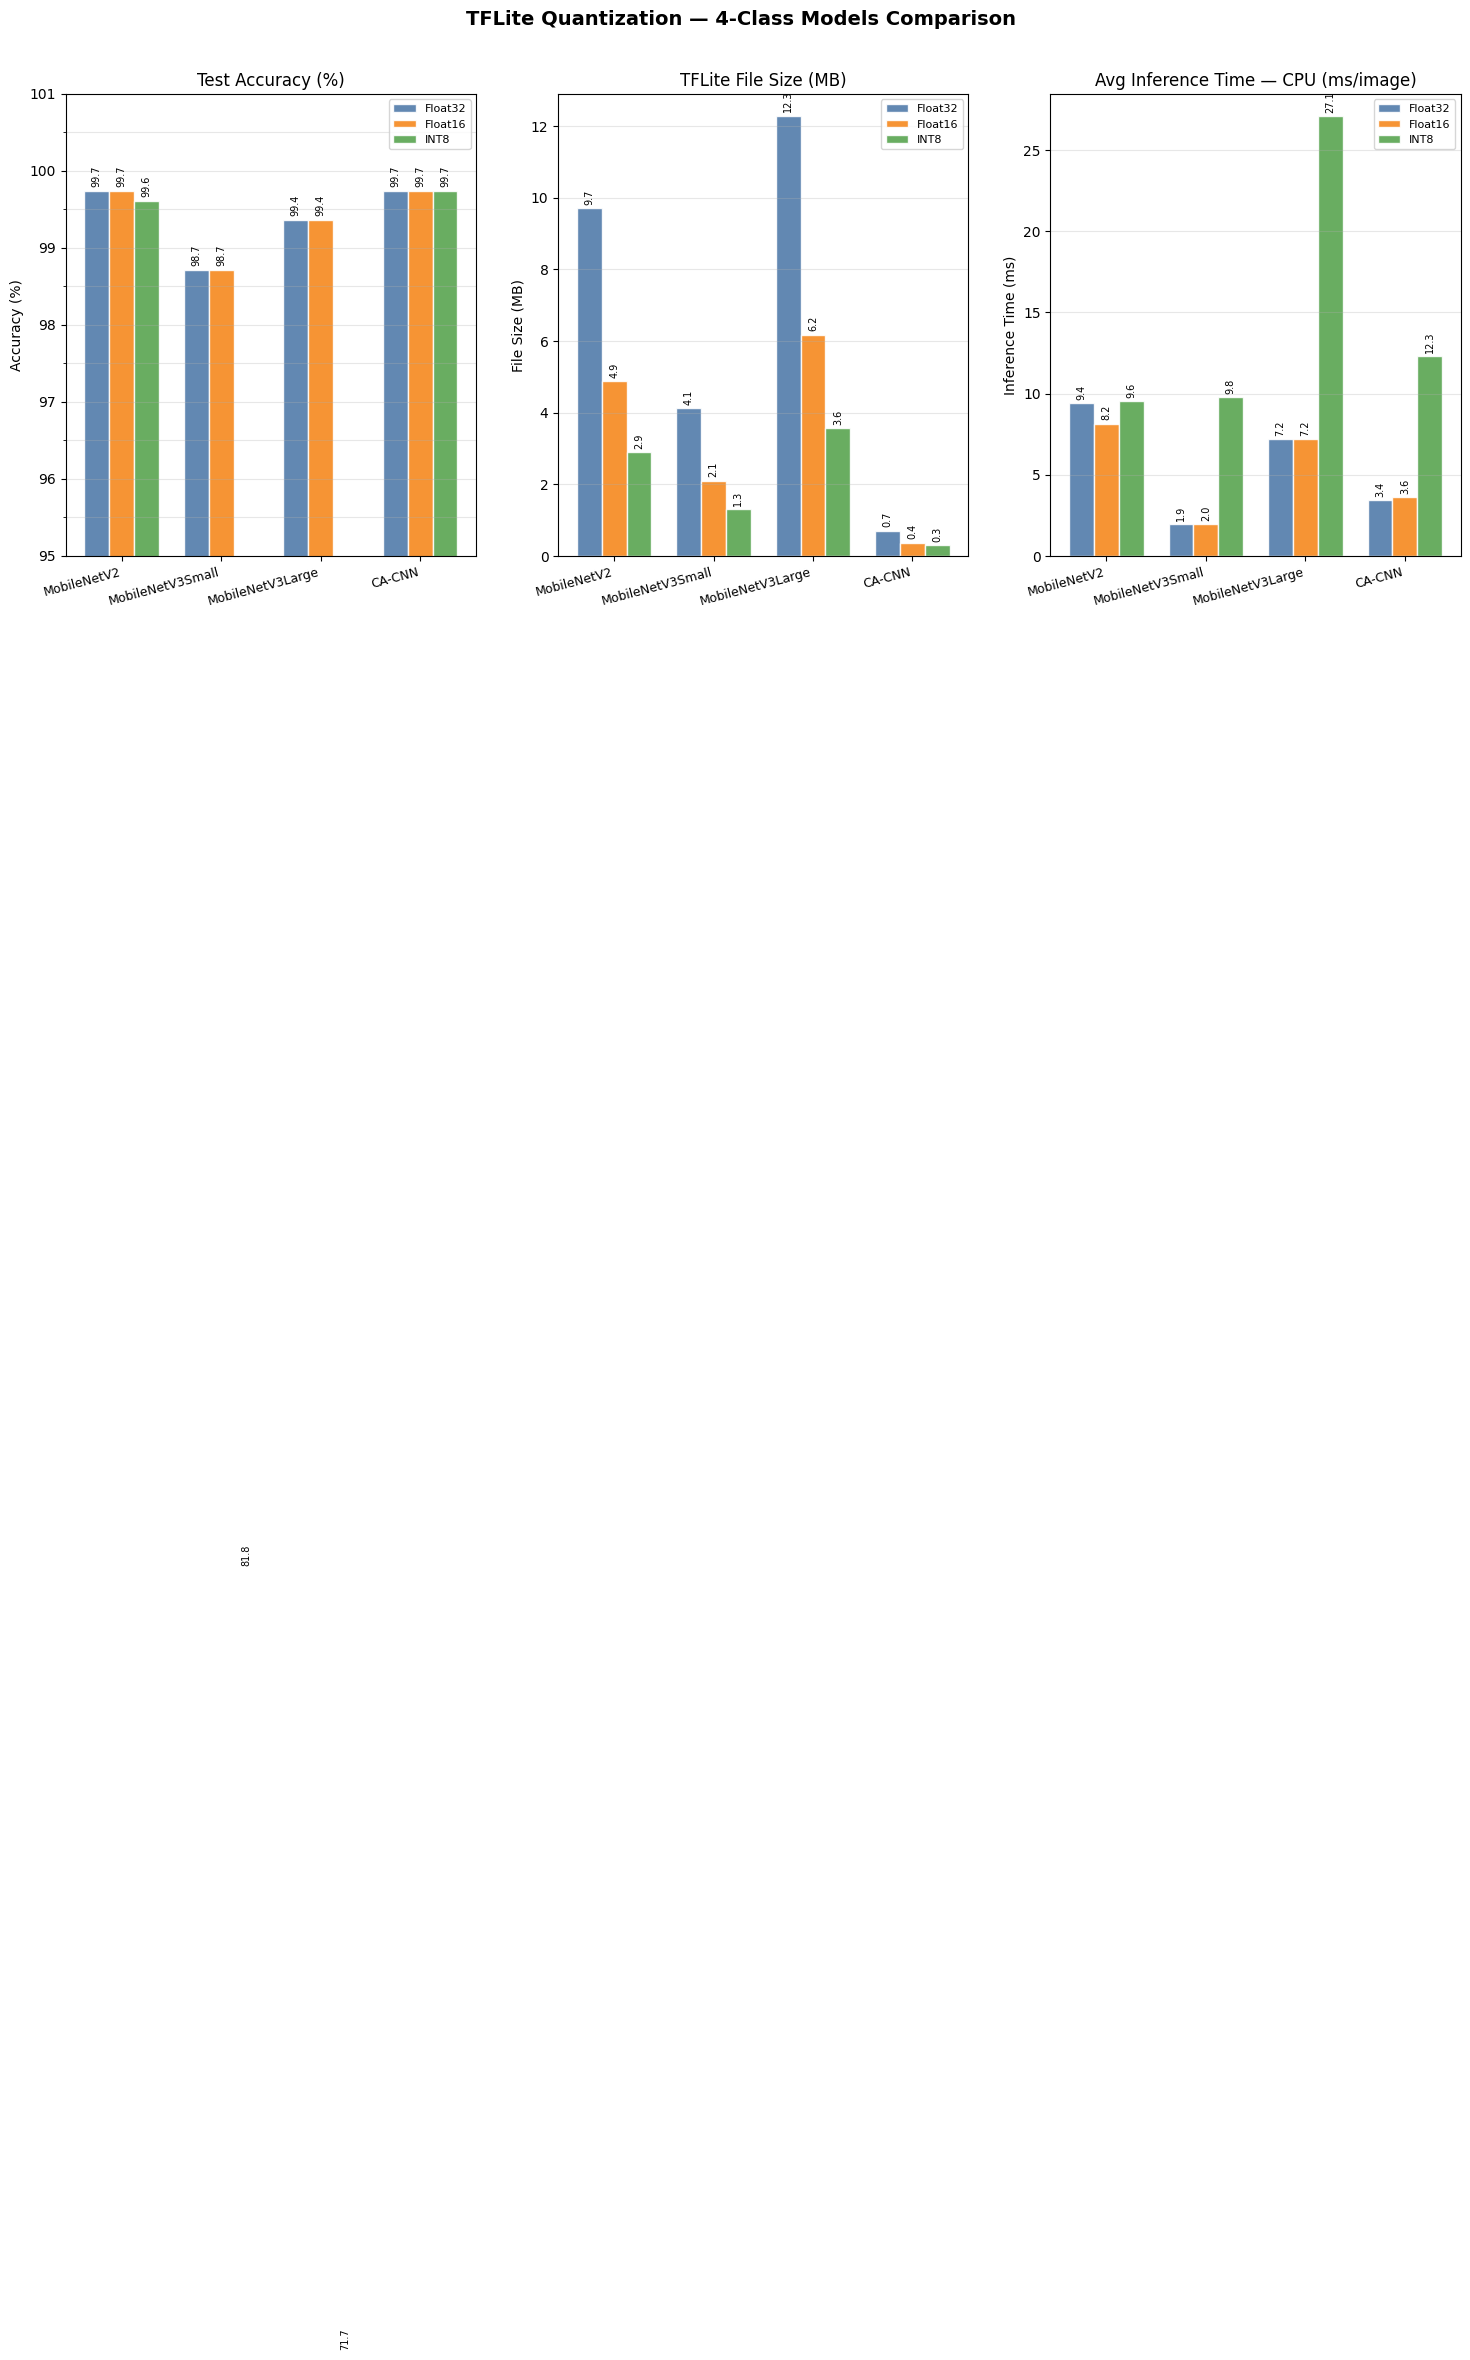

Chart saved → quantization_4class_comparison.png


In [18]:
MODEL_ORDER  = ["MobileNetV2", "MobileNetV3Small", "MobileNetV3Large", "CA-CNN"]
FORMAT_ORDER = ["float32", "float16", "int8"]
FORMAT_COLORS = {"float32": "#4C78A8", "float16": "#F58518", "int8": "#54A24B"}
FORMAT_LABELS = {"float32": "Float32", "float16": "Float16", "int8": "INT8"}

# ── Pivot helpers ─────────────────────────────────────────────────────────────
def pivot_metric(df, metric):
    return df.pivot(index="Model", columns="Format", values=metric).reindex(
        index=MODEL_ORDER, columns=FORMAT_ORDER
    )


df_acc  = pivot_metric(df, "Acc (%)")
df_size = pivot_metric(df, "Size (MB)")
df_inf  = pivot_metric(df, "Inf (ms)")

n_models = len(MODEL_ORDER)
n_fmts   = len(FORMAT_ORDER)
x        = np.arange(n_models)
width    = 0.25
offsets  = np.linspace(-(n_fmts - 1) / 2, (n_fmts - 1) / 2, n_fmts) * width

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "TFLite Quantization — 4-Class Models Comparison",
    fontsize=14, fontweight="bold", y=1.02
)

# ── Panel 1: Accuracy ─────────────────────────────────────────────────────────
ax = axes[0]
for i, fmt in enumerate(FORMAT_ORDER):
    vals = df_acc[fmt].values
    bars = ax.bar(x + offsets[i], vals, width,
                  label=FORMAT_LABELS[fmt],
                  color=FORMAT_COLORS[fmt], alpha=0.88, edgecolor="white")
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                    f"{v:.1f}", ha="center", va="bottom", fontsize=7, rotation=90)

ax.set_title("Test Accuracy (%)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(95, 101)
ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.5))
ax.grid(axis="y", alpha=0.3, which="both")
ax.legend(fontsize=8)

# ── Panel 2: File Size ────────────────────────────────────────────────────────
ax = axes[1]
for i, fmt in enumerate(FORMAT_ORDER):
    vals = df_size[fmt].values
    bars = ax.bar(x + offsets[i], vals, width,
                  label=FORMAT_LABELS[fmt],
                  color=FORMAT_COLORS[fmt], alpha=0.88, edgecolor="white")
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                    f"{v:.1f}", ha="center", va="bottom", fontsize=7, rotation=90)

ax.set_title("TFLite File Size (MB)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("File Size (MB)")
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=8)

# ── Panel 3: Inference Time ───────────────────────────────────────────────────
ax = axes[2]
for i, fmt in enumerate(FORMAT_ORDER):
    vals = df_inf[fmt].values
    bars = ax.bar(x + offsets[i], vals, width,
                  label=FORMAT_LABELS[fmt],
                  color=FORMAT_COLORS[fmt], alpha=0.88, edgecolor="white")
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                    f"{v:.1f}", ha="center", va="bottom", fontsize=7, rotation=90)

ax.set_title("Avg Inference Time — CPU (ms/image)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Inference Time (ms)")
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(BASE, "quantization_4class_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → quantization_4class_comparison.png")

### Accuracy vs. Size Scatter (efficiency frontier)

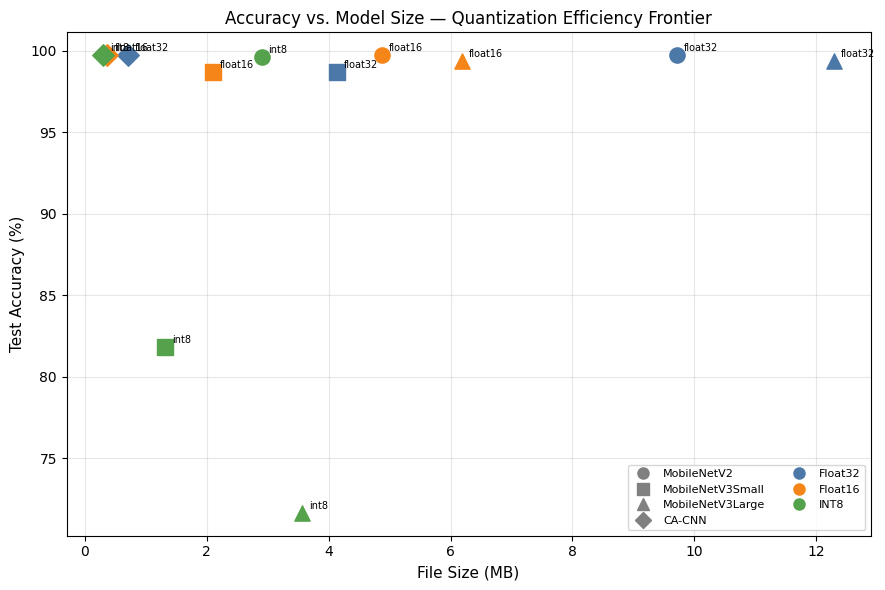

Scatter saved → quantization_4class_scatter.png


In [19]:
fig, ax = plt.subplots(figsize=(9, 6))

markers = {"MobileNetV2": "o", "MobileNetV3Small": "s",
           "MobileNetV3Large": "^", "CA-CNN": "D"}

for _, row in df.iterrows():
    ax.scatter(
        row["Size (MB)"], row["Acc (%)"],
        marker=markers[row["Model"]],
        color=FORMAT_COLORS[row["Format"]],
        s=120, zorder=3,
        label=f"{row['Model']} [{row['Format']}]"
    )
    ax.annotate(
        f"{row['Format']}",
        (row["Size (MB)"], row["Acc (%)"]),
        textcoords="offset points", xytext=(5, 3), fontsize=7
    )

ax.set_xlabel("File Size (MB)", fontsize=11)
ax.set_ylabel("Test Accuracy (%)", fontsize=11)
ax.set_title("Accuracy vs. Model Size — Quantization Efficiency Frontier", fontsize=12)
ax.grid(alpha=0.3)

# Custom legend: shapes = models, colours = formats
from matplotlib.lines import Line2D
handles = (
    [Line2D([0],[0], marker=m, color='grey', linestyle='None',
             markersize=8, label=n)
     for n, m in markers.items()]
    +
    [Line2D([0],[0], marker='o', color=c, linestyle='None',
             markersize=8, label=FORMAT_LABELS[f])
     for f, c in FORMAT_COLORS.items()]
)
ax.legend(handles=handles, fontsize=8, loc="lower right", ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "quantization_4class_scatter.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Scatter saved → quantization_4class_scatter.png")